In [1]:
# setup
import os
ds_size = 50
embed_models = [
    "all-MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2",
    "nomic-ai/nomic-embed-text-v1.5"
    ]
embed_models_dirnames = []
for name in embed_models:
    embed_models_dirnames.append(name.split("/")[-1])
ds_pos_results = []
cache_dir = os.path.join(os.getcwd(), "data", "hf-source")

# Acquiring the Source Dataset
Using Huggingface's Datasets we can easily load the wikipedia (20231101.en) dataset. Since we are focusing on encyclopedic data, this will serve as the base for testing the dataset generation pipeline.

In [2]:
from datasets import load_dataset

cache_dir = os.path.join(os.getcwd(), "data", "hf-source")
ds = load_dataset("wikimedia/wikipedia", "20231101.en", cache_dir=cache_dir)

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/41 [00:00<?, ?it/s]

In [3]:
# verification (optional)
print(f"Dataset length: {len(ds['train'])}")
print(ds['train'][0])
print(ds['train'][-1])

Dataset length: 6407814
{'id': '12', 'url': 'https://en.wikipedia.org/wiki/Anarchism', 'title': 'Anarchism', 'text': 'Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism. Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations. As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism).\n\nHumans have lived in societies without formal hierarchies long before the establishment of states, realms, or empires. With the rise of organised hierarchical bodies, scepticism toward authority also rose. Although traces of anarchist ideas are found all throughout history, modern anarchism emerged from t

In [4]:
# create subset for dev
ds_shuffled = ds.shuffle(seed=97)
if ds_size > 0:
    ds_subset = ds_shuffled['train'].select(range(ds_size))
else:
    ds_subset = ds_shuffled['train']
print(f"Test subset length: {len(ds_subset)}")
print(f"Sample entry: {ds_subset[0]['title']}")

Test subset length: 50
Sample entry: Processing delay


# Embedding Generation

In [5]:
from sentence_transformers import SentenceTransformer

for model_name in embed_models:
    dirname = model_name.split("/")[-1]
    ds_embed_dir = os.path.join(os.getcwd(), "data", "ds_embed", dirname, str(ds_size))

    # generate embeddings and extract tokens
    model = SentenceTransformer(model_name, trust_remote_code=True)
    tokenizer = model.tokenizer
    print(f"Model: {model_name}")
    print(f"Tokenizer: {tokenizer}")
    print(f"Vocab size: {len(tokenizer.vocab)}")
    print(f"Max length: {tokenizer.model_max_length}")
    
    texts = [entry['text'] for entry in ds_subset]
    print(f"Generating embeddings and extracting tokens for {len(texts)} entries...")
    
    # Generate embeddings
    embeddings = model.encode(texts, show_progress_bar=True, batch_size=1)
    print(f"Generated embeddings with shape: {embeddings.shape}")
    
    # Extract tokens for each text
    all_tokens = []
    all_token_ids = []
    
    for text in texts:
        # Tokenize the text (returns list of token strings)
        tokens = tokenizer.tokenize(text)
        # Convert to token IDs (returns list of integers)
        token_ids = tokenizer.convert_tokens_to_ids(tokens)
        
        all_tokens.append(tokens)
        all_token_ids.append(token_ids)
    
    print(f"Example tokens for first text (first 10): {all_tokens[0][:10]}")
    print(f"Example token IDs for first text (first 10): {all_token_ids[0][:10]}")
    print(f"Number of tokens for first text: {len(all_tokens[0])}")
    
    # Add embeddings, tokens, and token IDs to dataset
    ds_embed = ds_subset.add_column("embeddings", embeddings.tolist())
    ds_embed = ds_embed.add_column("tokens", all_tokens)
    ds_embed = ds_embed.add_column("token_ids", all_token_ids)
    print(f"Dataset columns: {ds_embed.column_names}")

    # save dataset with embeddings and tokens
    print(f"Saving dataset with embeddings and tokens to: {ds_embed_dir}")
    ds_embed.save_to_disk(ds_embed_dir)
    print("Dataset saved successfully!")
    print("-" * 60)

Model: all-MiniLM-L6-v2
Tokenizer: BertTokenizerFast(name_or_path='sentence-transformers/all-MiniLM-L6-v2', vocab_size=30522, model_max_length=256, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)
Vocab size: 30522
Max length: 256
Generating embeddings and extracting

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (262 > 256). Running this sequence through the model will result in indexing errors


Generated embeddings with shape: (50, 384)
Example tokens for first text (first 10): ['in', 'a', 'network', 'based', 'on', 'packet', 'switching', ',', 'processing', 'delay']
Example token IDs for first text (first 10): [1999, 1037, 2897, 2241, 2006, 14771, 11991, 1010, 6364, 8536]
Number of tokens for first text: 262
Dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids']
Saving dataset with embeddings and tokens to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/data/ds_embed/all-MiniLM-L6-v2/50
Dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids']
Saving dataset with embeddings and tokens to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/data/ds_embed/all-MiniLM-L6-v2/50


Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

...

Model: nomic-ai/nomic-embed-text-v1.5
Tokenizer: BertTokenizerFast(name_or_path='nomic-ai/nomic-embed-text-v1.5', vocab_size=30522, model_max_length=8192, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)
Vocab size: 30522
Max length: 8192
Generating embeddings and ext

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Generated embeddings with shape: (50, 768)
Example tokens for first text (first 10): ['in', 'a', 'network', 'based', 'on', 'packet', 'switching', ',', 'processing', 'delay']
Example token IDs for first text (first 10): [1999, 1037, 2897, 2241, 2006, 14771, 11991, 1010, 6364, 8536]
Number of tokens for first text: 262
Dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids']
Saving dataset with embeddings and tokens to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/data/ds_embed/nomic-embed-text-v1.5/50
Dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids']
Saving dataset with embeddings and tokens to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/data/ds_embed/nomic-embed-text-v1.5/50


Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset saved successfully!
------------------------------------------------------------


# Preprocessing


In [6]:
import numpy as np
from numpy import ndarray
from datasets import Dataset, DatasetDict
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA


def prep(data: Dataset | DatasetDict) -> ndarray:
    # L2-normalization (to euclidean instead of cosine)
    embeddings_array = np.asarray(data, dtype=np.float32)
    embeddings_norm = normalize(embeddings_array, norm="l2", axis=1)

    # PCA red to 50 dims: De-noising and speedup
    pca = PCA(n_components=50, random_state=97, svd_solver="auto", whiten=False)
    data = pca.fit_transform(embeddings_norm)
    return data

# Pipeline A (UMAP)
Based on [`knoto`](https://github.com/whatphilipcodes/knoto), this pipeline uses `UMAP` to reduce `sBERT` embeddings into two (spatial) dimensions.

In [7]:
import umap
from datasets import load_from_disk

for dirname in embed_models_dirnames:
    ds_embed_dir = os.path.join(os.getcwd(), "data", "ds_embed", dirname, str(ds_size))
    ds_pos_dir = os.path.join(os.getcwd(), "data", "ds_pos", dirname, "umap", str(ds_size))

    ds_embed = load_from_disk(ds_embed_dir)
    print(f"Loaded dataset with {len(ds_embed)} entries")

    # collect embeddings
    embeddings_array = prep(ds_embed['embeddings'])
    print(f"Embeddings shape: {embeddings_array.shape}")

    # apply UMAP reduction
    reducer = umap.UMAP(n_components=2, random_state=97, init="pca")
    print("Applying UMAP reduction...")
    embed_reduced = reducer.fit_transform(embeddings_array)
    print(f"2D embeddings shape: {embed_reduced.shape}")

    # add to ds
    ds_pos = ds_embed.add_column("x", embed_reduced[:, 0].tolist())
    ds_pos = ds_pos.add_column("y", embed_reduced[:, 1].tolist())
    print(f"Final dataset columns: {ds_pos.column_names}")

    # save ds with positions
    ds_pos.save_to_disk(ds_pos_dir)
    ds_pos_results.append(ds_pos_dir)
    print("Dataset with UMAP positions saved successfully!")

Loaded dataset with 50 entries
Embeddings shape: (50, 50)
Applying UMAP reduction...


/Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embeddings shape: (50, 2)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids', 'x', 'y']


Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset with UMAP positions saved successfully!
Loaded dataset with 50 entries
Embeddings shape: (50, 50)
Applying UMAP reduction...
2D embeddings shape: (50, 2)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids', 'x', 'y']


...

Dataset with UMAP positions saved successfully!
Loaded dataset with 50 entries
Embeddings shape: (50, 50)
Applying UMAP reduction...


/Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embeddings shape: (50, 2)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids', 'x', 'y']


Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset with UMAP positions saved successfully!


# Pipeline B (t-SNE)
based on the `scikit-learn` implementation of `t-SNE`.

In [8]:
from sklearn.manifold import TSNE
from datasets import load_from_disk

for dirname in embed_models_dirnames:
    ds_embed_dir = os.path.join(os.getcwd(), "data", "ds_embed", dirname, str(ds_size))
    ds_pos_dir = os.path.join(os.getcwd(), "data", "ds_pos", dirname, "tsne", str(ds_size))

    # load dataset with embeddings (reuse from UMAP pipeline)
    ds_embed = load_from_disk(ds_embed_dir)
    print(f"Loaded dataset with {len(ds_embed)} entries")

    # collect embeddings
    embeddings_array = prep(ds_embed['embeddings'])
    print(f"Embeddings shape: {embeddings_array.shape}")

    # apply t-SNE reduction
    tsne = TSNE(n_components=2, random_state=97, init="pca")
    print("Applying t-SNE reduction...")
    embed_reduced_tsne = tsne.fit_transform(embeddings_array)
    print(f"2D t-SNE embeddings shape: {embed_reduced_tsne.shape}")

    # add to dataset
    ds_pos_tsne = ds_embed.add_column("x", embed_reduced_tsne[:, 0].tolist())
    ds_pos_tsne = ds_pos_tsne.add_column("y", embed_reduced_tsne[:, 1].tolist())
    print(f"Final dataset columns: {ds_pos_tsne.column_names}")

    # save dataset with t-SNE positions
    ds_pos_tsne.save_to_disk(ds_pos_dir)
    ds_pos_results.append(ds_pos_dir)
    print("Dataset with t-SNE positions saved successfully!")

Loaded dataset with 50 entries
Embeddings shape: (50, 50)
Applying t-SNE reduction...


/Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/.venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


2D t-SNE embeddings shape: (50, 2)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids', 'x', 'y']


Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset with t-SNE positions saved successfully!
Loaded dataset with 50 entries
Embeddings shape: (50, 50)
Applying t-SNE reduction...
2D t-SNE embeddings shape: (50, 2)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids', 'x', 'y']
2D t-SNE embeddings shape: (50, 2)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids', 'x', 'y']


Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset with t-SNE positions saved successfully!
Loaded dataset with 50 entries
Embeddings shape: (50, 50)
Applying t-SNE reduction...
2D t-SNE embeddings shape: (50, 2)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids', 'x', 'y']
2D t-SNE embeddings shape: (50, 2)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'tokens', 'token_ids', 'x', 'y']


Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset with t-SNE positions saved successfully!


# Visualization

Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/all-MiniLM-L6-v2_umap_50_20250908T164329.pdf


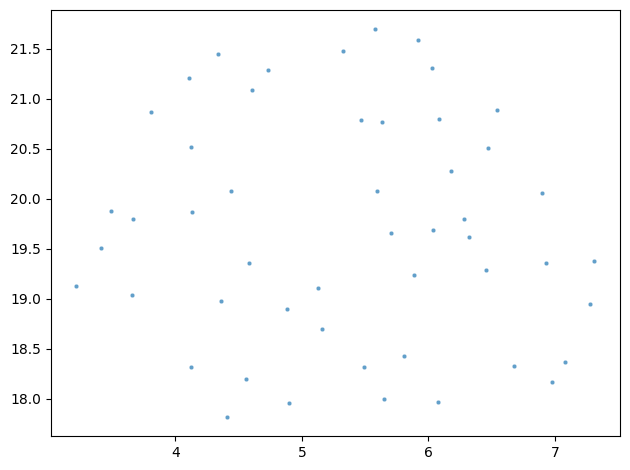

Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/all-mpnet-base-v2_umap_50_20250908T164329.pdf


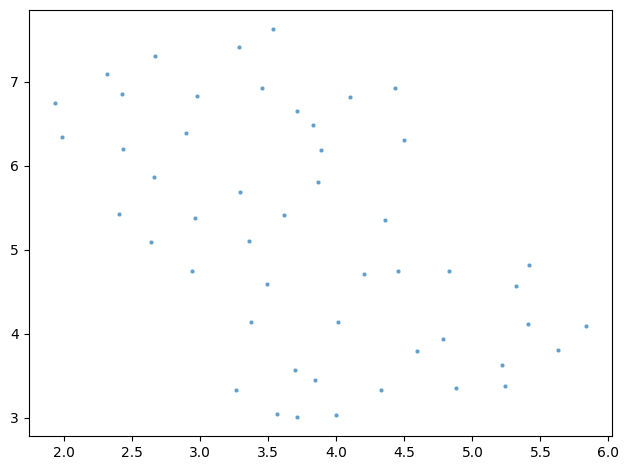

Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/nomic-embed-text-v1.5_umap_50_20250908T164329.pdf


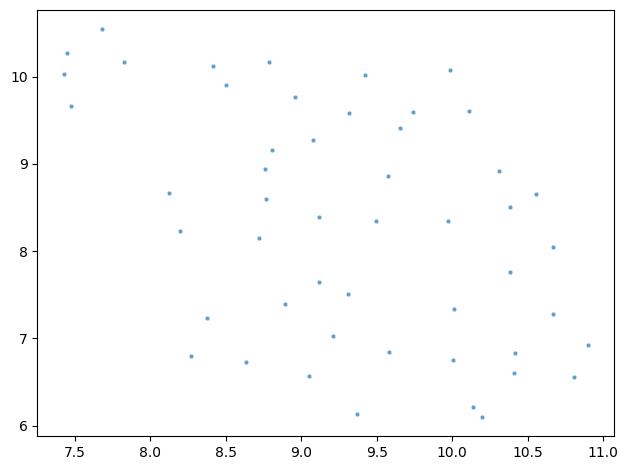

Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/all-MiniLM-L6-v2_tsne_50_20250908T164329.pdf


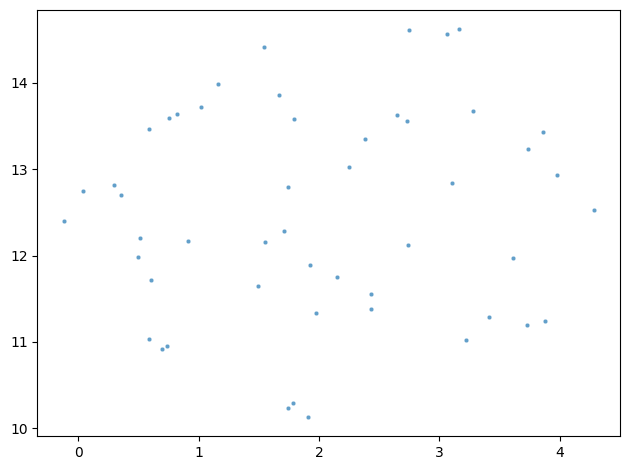

Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/all-mpnet-base-v2_tsne_50_20250908T164330.pdf


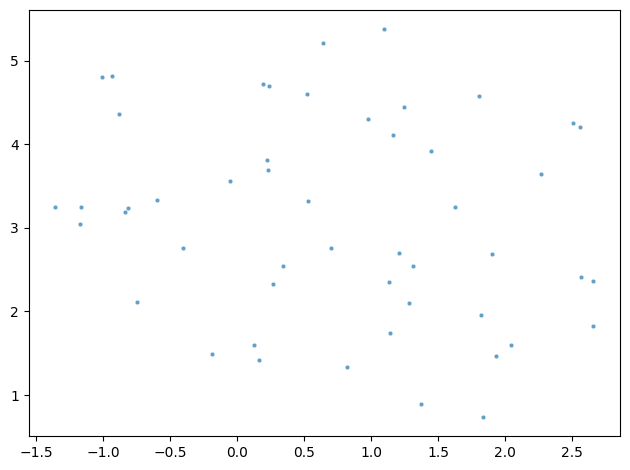

Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/nomic-embed-text-v1.5_tsne_50_20250908T164330.pdf


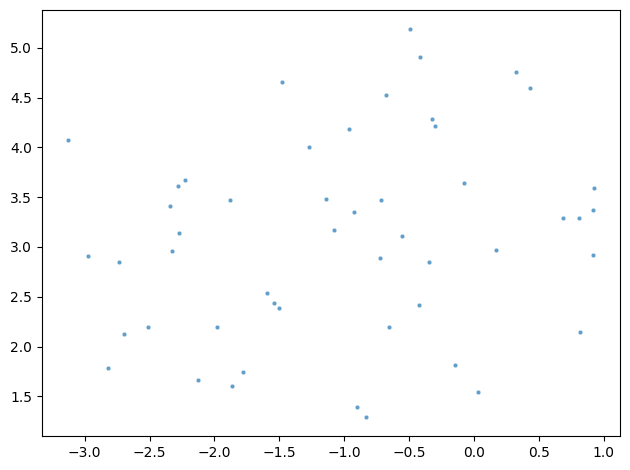

In [9]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

img_dir = os.path.join(os.getcwd(), "img")
# Ensure img directory exists
os.makedirs(img_dir, exist_ok=True)

for dir in ds_pos_results:
    ds_pos = load_from_disk(dir)

    xs = ds_pos["x"]
    ys = ds_pos["y"]

    plt.figure()
    sns.scatterplot(
        x=xs,
        y=ys,
        s=10,
        alpha=0.7
    )
    # plt.axis("off")
    plt.tight_layout()
    
    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
    # Extract directory name parts for filename
    dir_parts = dir.replace(os.getcwd(), "").strip(os.sep).split(os.sep)
    # Create filename: embedding_model_reduction_method_size_timestamp
    filename = f"{dir_parts[2]}_{dir_parts[3]}_{dir_parts[4]}_{timestamp}.pdf"
    filepath = os.path.join(img_dir, filename)
    
    # Save the plot as PDF (vector format, best for LaTeX)
    plt.savefig(filepath, format='pdf', bbox_inches='tight')
    print(f"Saved plot to: {filepath}")
    
    plt.show()